0. Read Chapters 1-5 in Martin book, https://subscription.packtpub.com/book/data/9781805127161/3

1. Fitting distribution 1:
- Create a data set using 30 draws from uniform distribution on [2,5]
- Use arviz to explore the data
- Create a PYMC model fitting it with Uniform distribution
- Plot posterior distribution
- Plot posterior predictive checks
- Explain the meaning of posterior distributions

[3.12362036 4.85214292 4.19598183 3.79597545 2.46805592 2.46798356
 2.17425084 4.59852844 3.80334504 4.12421773 2.06175348 4.90972956
 4.49732792 2.63701733 2.5454749  2.55021353 2.91272673 3.57426929
 3.29583506 2.87368742 3.83555868 2.41848158 2.87643395 3.09908553
 3.36820995 4.35552788 2.59902135 3.54270332 3.77724371 2.13935124]


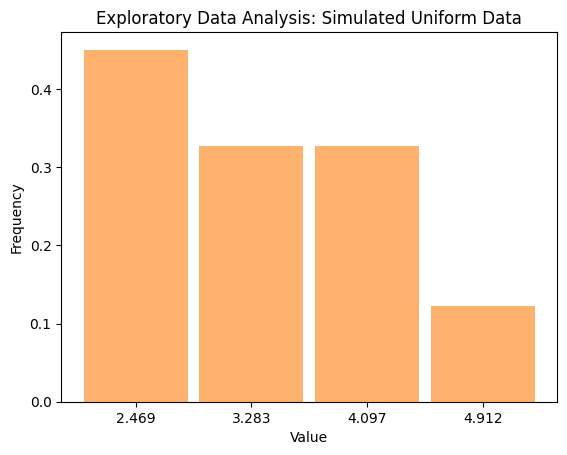

Output()

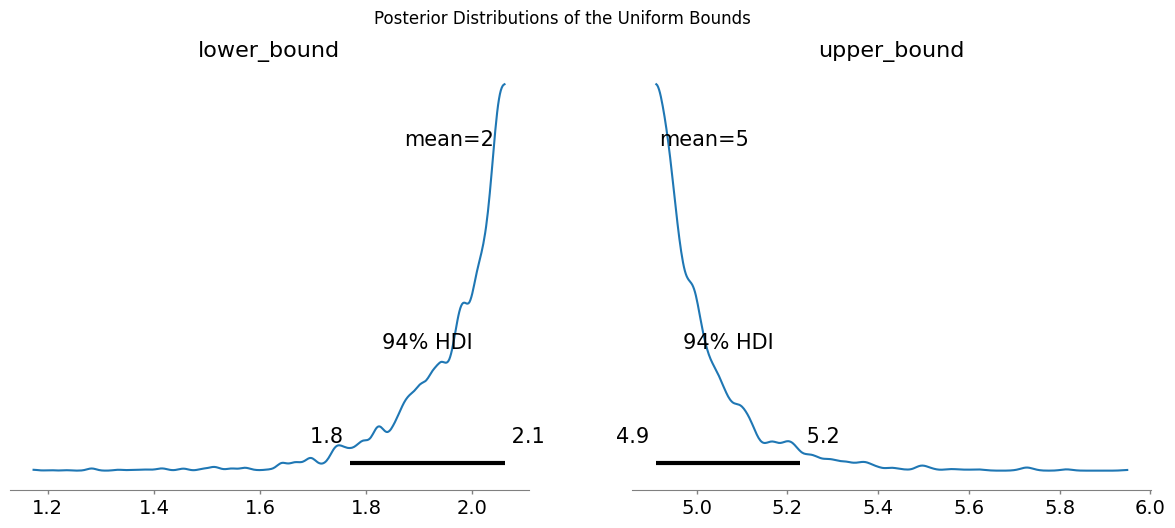

Output()

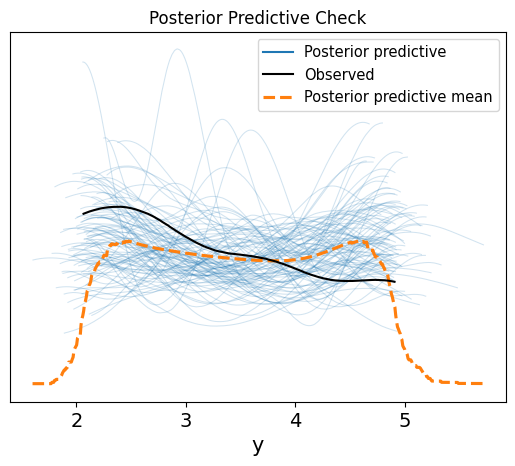

In [ ]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)
data = np.random.uniform(low=2, high=5, size=30)
print(data)


az.plot_dist(data, kind="hist", color="C1", hist_kwargs={"alpha": 0.6})
plt.title("Exploratory Data Analysis: Simulated Uniform Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


with pm.Model() as uniform_model:

    lower_bound = pm.Uniform('lower_bound', lower=0, upper=np.min(data))
    upper_bound = pm.Uniform('upper_bound', lower=np.max(data), upper=10)

    y = pm.Uniform('y', lower=lower_bound, upper=upper_bound, observed=data)


    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, tune=1000, return_inferencedata=True)


az.plot_posterior(trace)
plt.suptitle("Posterior Distributions of the Uniform Bounds")
plt.show()


with uniform_model:

    pm.sample_posterior_predictive(trace, extend_inferencedata=True)

az.plot_ppc(trace, num_pp_samples=100)
plt.title("Posterior Predictive Check")
plt.show()

The posterior distribution is the core concept of Bayesian inference. It represents our updated knowledge (or beliefs) about the model's parameters after we have observed the data.

Before seeing any data, we establish priors (our initial, often broad assumptions about what the parameters might be). We then combine these priors with the likelihood of the actual data we observed (the 30 simulated points) using Bayes' theorem

2. Fitting distribution 2:
- Create a data set using 30 draws from uniform distribution on [2,5]
- Use arviz to explore the data
- Create a PYMC model fitting it with Beta distribution
- Plot posterior distribution
- Plot posterior predictive checks
- Explain the meaning of posterior predictive checks

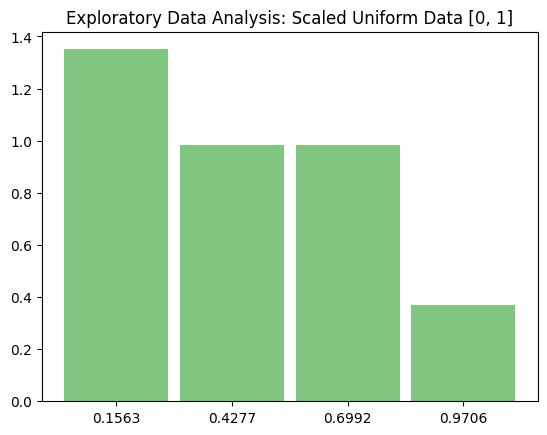

Output()

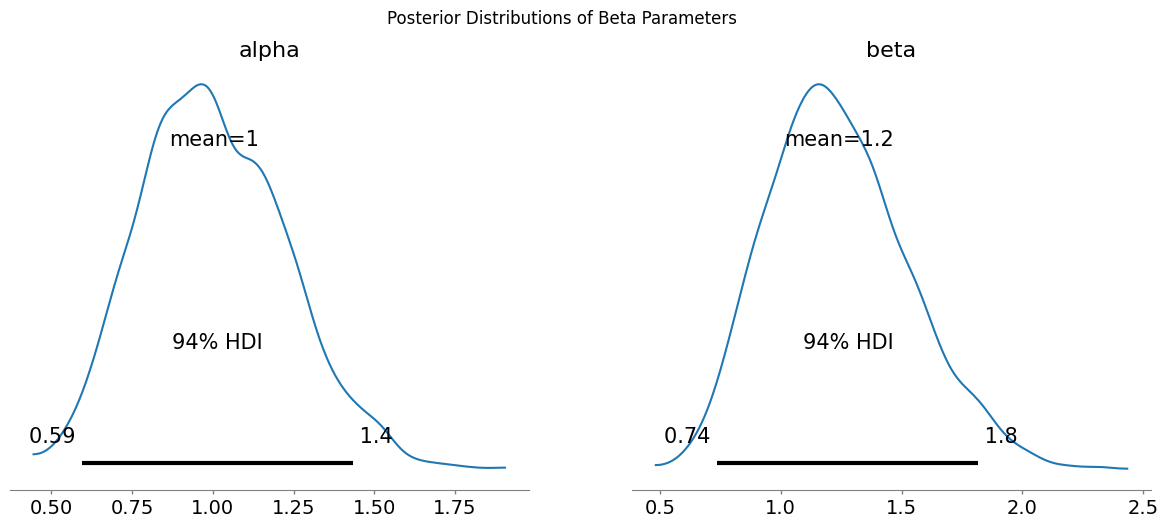

Output()

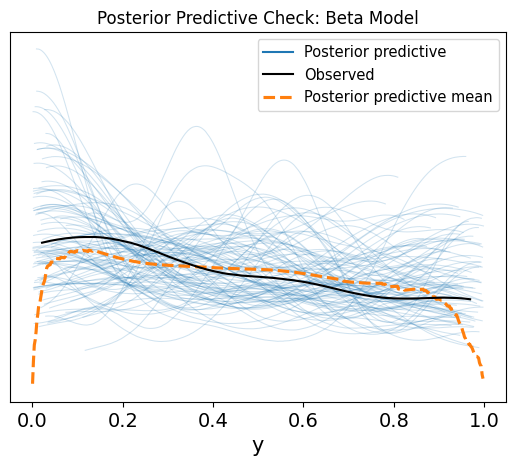

In [ ]:
scaled_data = (data - 2) / (5 - 2)

az.plot_dist(scaled_data, kind="hist", color="C2", hist_kwargs={"alpha": 0.6})
plt.title("Exploratory Data Analysis: Scaled Uniform Data [0, 1]")
plt.show()

with pm.Model() as beta_model:
    alpha = pm.Exponential('alpha', lam=1.0)
    beta = pm.Exponential('beta', lam=1.0)

    y = pm.Beta('y', alpha=alpha, beta=beta, observed=scaled_data)

    trace_beta = pm.sample(2000, tune=1000, return_inferencedata=True)


az.plot_posterior(trace_beta)
plt.suptitle("Posterior Distributions of Beta Parameters")
plt.show()

with beta_model:
    pm.sample_posterior_predictive(trace_beta, extend_inferencedata=True)

az.plot_ppc(trace_beta, num_pp_samples=100)
plt.title("Posterior Predictive Check: Beta Model")
plt.show()

A Posterior Predictive Check tests how well your model fits reality by using it to generate new, simulated data. If that simulated data closely resembles your actual observed data, it proves your model accurately learned the underlying patterns.

3. Fitting line
- Import Iris Data set
- Plot Sepal length as a function of Sepal width
- Build PYMC linear model
- Plot posteriors as marginal and joint distributions
- Plot posterior predictive checks
- Rationalize the behavior of joint distribution between slope and intersect

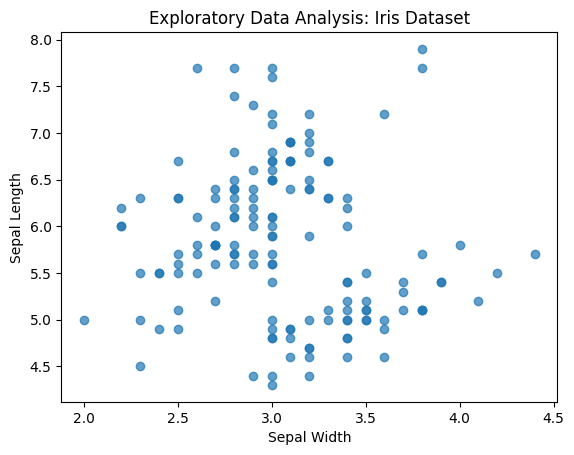

Output()

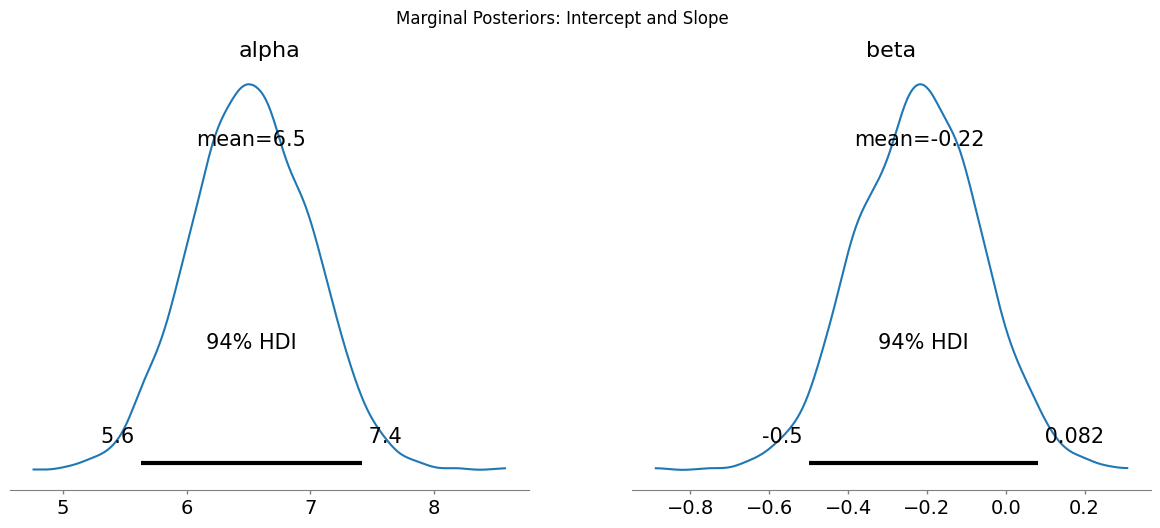

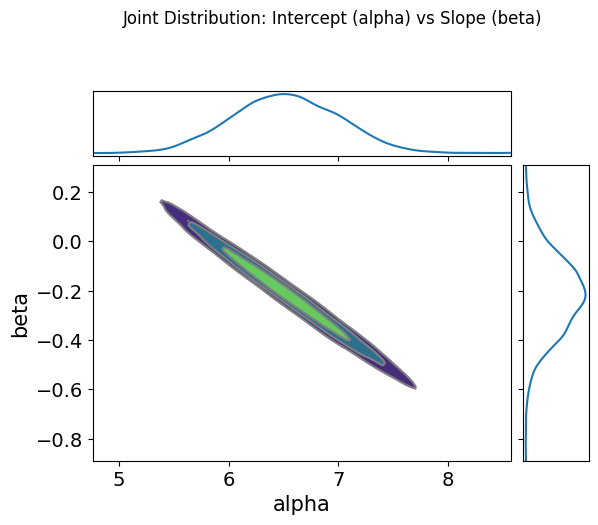

Output()

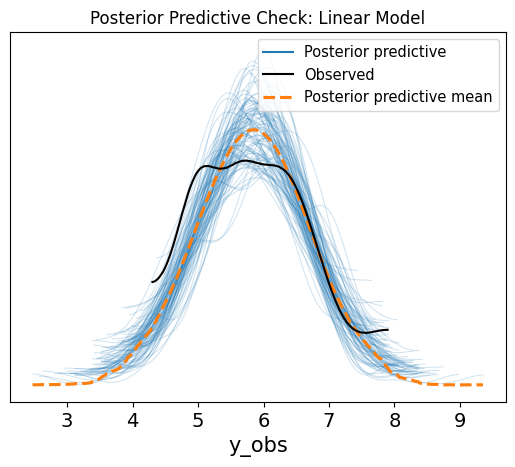

In [ ]:
import pymc as pm
import seaborn as sns


iris = sns.load_dataset('iris')
x_data = iris['sepal_width'].values
y_data = iris['sepal_length'].values


plt.scatter(x_data, y_data, alpha=0.7, color='C0')
plt.xlabel('Sepal Width')
plt.ylabel('Sepal Length')
plt.title('Exploratory Data Analysis: Iris Dataset')
plt.show()

with pm.Model() as linear_model:

    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10)

    sigma = pm.HalfNormal('sigma', sigma=5)

    mu = alpha + beta * x_data

    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)

    trace_linear = pm.sample(2000, tune=1000, return_inferencedata=True)


az.plot_posterior(trace_linear, var_names=['alpha', 'beta'])
plt.suptitle('Marginal Posteriors: Intercept and Slope')
plt.show()


az.plot_pair(trace_linear, var_names=['alpha', 'beta'], kind='kde', marginals=True)
plt.suptitle('Joint Distribution: Intercept (alpha) vs Slope (beta)', y=1.05)
plt.show()


with linear_model:
   pm.sample_posterior_predictive(trace_linear, extend_inferencedata=True)

az.plot_ppc(trace_linear, num_pp_samples=100)
plt.title('Posterior Predictive Check: Linear Model')
plt.show()

4. Fitting plane
- Import Iris Data set
- Plot Sepal length as a function of Petal Length and Petal width
- Build PYMC linear model
- Plot posteriors
- Plot posterior predictive checks

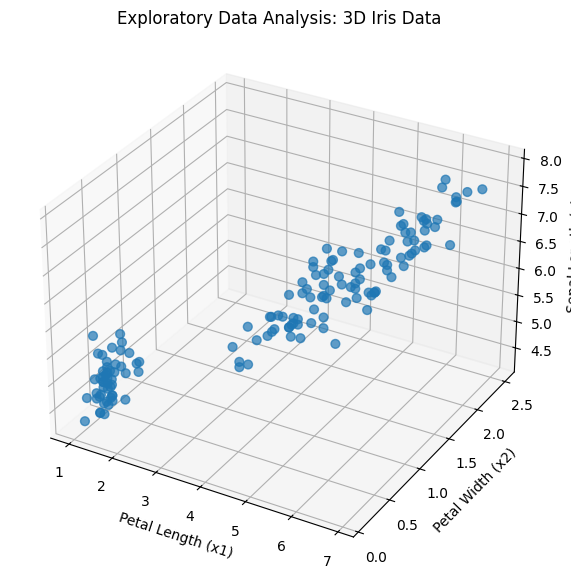

Output()

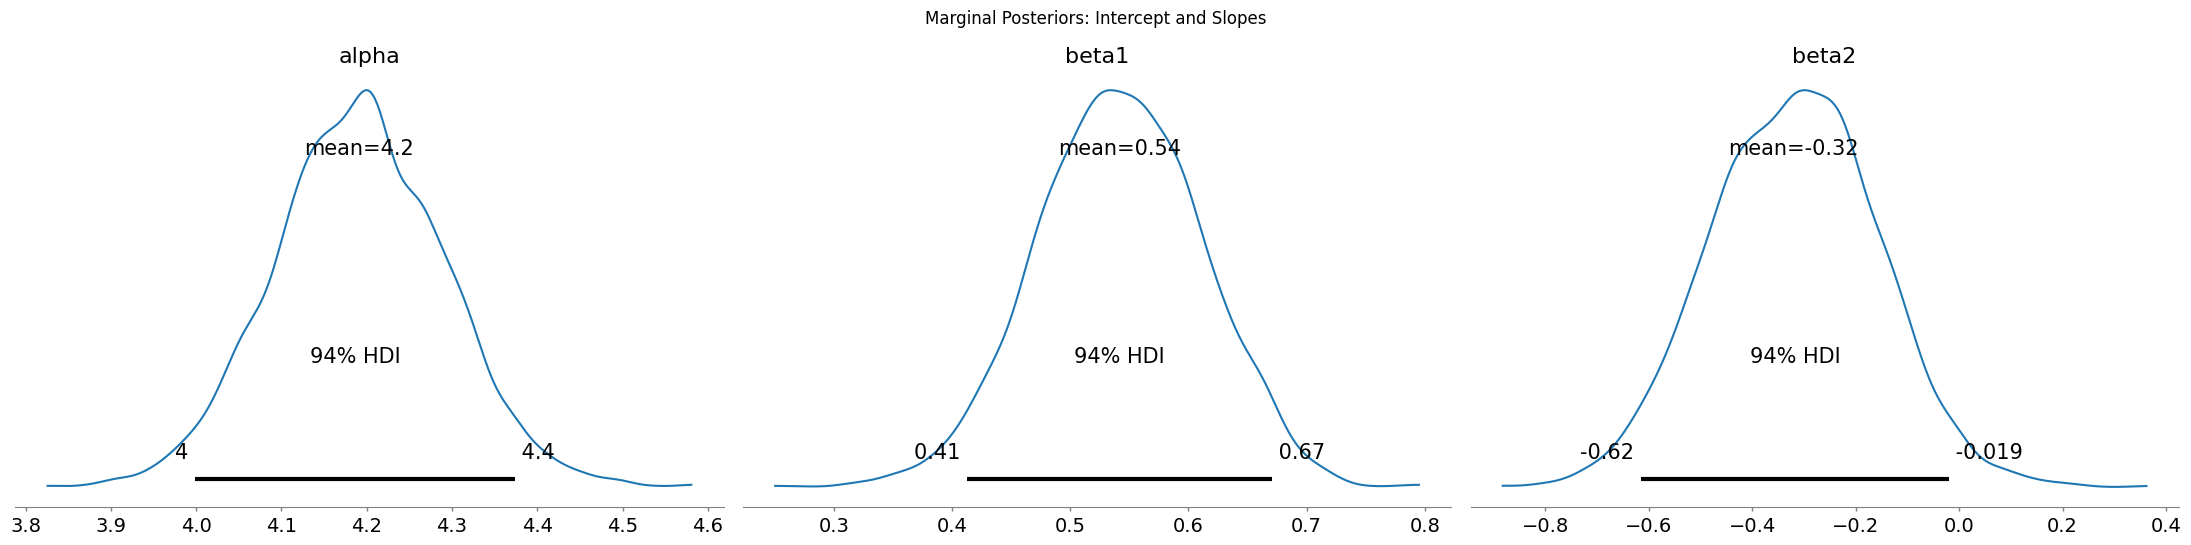

Output()

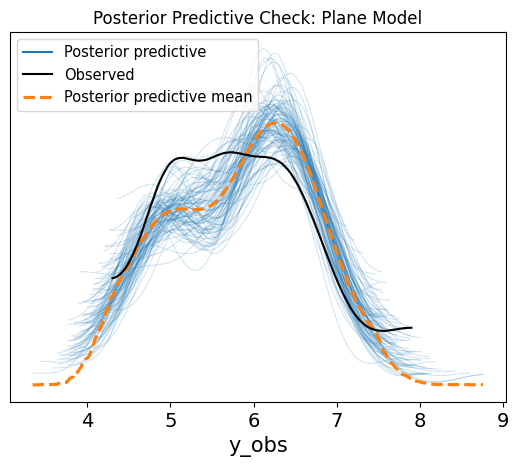

In [ ]:
x1_data = iris['petal_length'].values
x2_data = iris['petal_width'].values
y_data = iris['sepal_length'].values


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1_data, x2_data, y_data, c='C0', marker='o', s=40, alpha=0.7)

ax.set_xlabel('Petal Length (x1)')
ax.set_ylabel('Petal Width (x2)')
ax.set_zlabel('Sepal Length (y)')
plt.title('Exploratory Data Analysis: 3D Iris Data')
plt.show()

with pm.Model() as plane_model:

    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta1 = pm.Normal('beta1', mu=0, sigma=10)
    beta2 = pm.Normal('beta2', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)

    mu = alpha + (beta1 * x1_data) + (beta2 * x2_data)

    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)

    trace_plane = pm.sample(2000, tune=1000, return_inferencedata=True)

az.plot_posterior(trace_plane, var_names=['alpha', 'beta1', 'beta2'])
plt.suptitle('Marginal Posteriors: Intercept and Slopes')
plt.tight_layout()
plt.show()

with plane_model:
    pm.sample_posterior_predictive(trace_plane, extend_inferencedata=True)

az.plot_ppc(trace_plane, num_pp_samples=100)
plt.title('Posterior Predictive Check: Plane Model')
plt.show()

5. Build Hierarchical model
- Import Iris data set
- Fit Sepal Length as a function of Sepal Width for three groups as hierarchical model
- Explain the meanings of the hyperparameters proprs and parameters priors

Output()

ERROR:pymc.stats.convergence:There were 21 divergences after tuning. Increase `target_accept` or reparameterize.


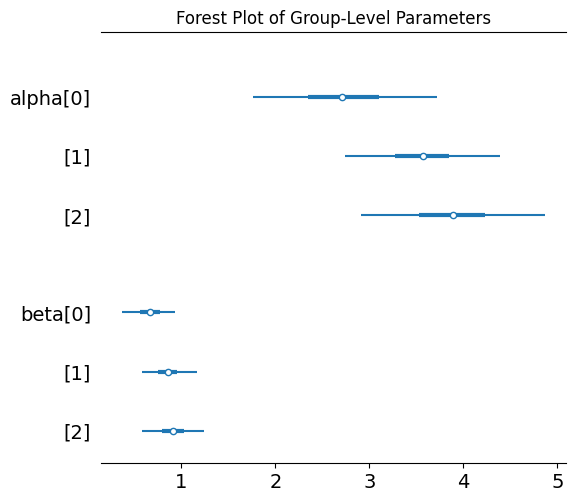

In [2]:

iris = sns.load_dataset('iris')

x_data = iris['sepal_width'].values
y_data = iris['sepal_length'].values


species_idx, species_names = pd.factorize(iris['species'])
n_species = len(species_names)


with pm.Model() as hierarchical_model:


    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=10)
    mu_beta = pm.Normal('mu_beta', mu=0, sigma=10)

    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=5)
    sigma_beta = pm.HalfNormal('sigma_beta', sigma=5)


    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_species)
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_species)

    eps = pm.HalfNormal('eps', sigma=5)


    mu = alpha[species_idx] + beta[species_idx] * x_data

    y_obs = pm.Normal('y_obs', mu=mu, sigma=eps, observed=y_data)


    trace_hierarch = pm.sample(2000, tune=1000, target_accept=0.99, return_inferencedata=True)


az.plot_forest(trace_hierarch, var_names=['alpha', 'beta'], combined=True)
plt.title('Forest Plot of Group-Level Parameters')
plt.show()

Output()

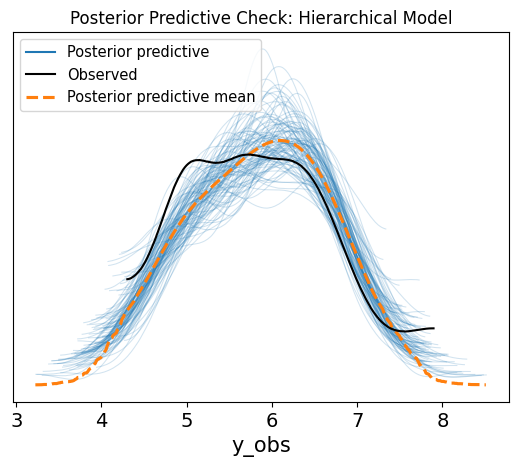

In [3]:
with hierarchical_model:
    pm.sample_posterior_predictive(trace_hierarch, extend_inferencedata=True)

az.plot_ppc(trace_hierarch, num_pp_samples=100)
plt.title('Posterior Predictive Check: Hierarchical Model')
plt.show()